<a href="https://colab.research.google.com/github/Kohei-200/math/blob/main/XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## XGBoost in Python
reference:
[
XGBoost in Python from Start to Finish](https://www.youtube.com/watch?v=GrJP9FLV3FE&list=TLPQMTcwNTIwMjbg11R8ZLM_eg&index=1)
StatQuest

### Intro

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, make_scorer, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
for i in df.columns:
  print(i, df[i].nunique())

customerID 7043
gender 2
SeniorCitizen 2
Partner 2
Dependents 2
tenure 73
PhoneService 2
MultipleLines 3
InternetService 3
OnlineSecurity 3
OnlineBackup 3
DeviceProtection 3
TechSupport 3
StreamingTV 3
StreamingMovies 3
Contract 3
PaperlessBilling 2
PaymentMethod 4
MonthlyCharges 1585
TotalCharges 6531
Churn 2


In [5]:
for col in df.columns:
  df[col].replace(["-", " "], "_", regex = True, inplace = True)

/tmp/ipykernel_53897/2757593082.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace(["-", " "], "_", regex = True, inplace = True)


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590_VHVEG,Female,0,Yes,No,1,No,No_phone_service,DSL,No,...,No,No,No,No,Month_to_month,Yes,Electronic_check,29.85,29.85,No
1,5575_GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One_year,No,Mailed_check,56.95,1889.5,No
2,3668_QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month_to_month,Yes,Mailed_check,53.85,108.15,Yes
3,7795_CFOCW,Male,0,No,No,45,No,No_phone_service,DSL,Yes,...,Yes,Yes,No,No,One_year,No,Bank_transfer_(automatic),42.30,1840.75,No
4,9237_HQITU,Female,0,No,No,2,Yes,No,Fiber_optic,No,...,No,No,No,No,Month_to_month,Yes,Electronic_check,70.70,151.65,Yes


In [7]:
X = df.drop(["Churn"], axis = 1).copy()
y = df["Churn"].copy()

### Cleaning

In [8]:
# binary encoding
X = pd.get_dummies(X, columns=[
    col for col in X.columns if X[col].nunique() == 2
    ], drop_first=True, dtype = int)

In [9]:
X

,customerID,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes
0,7590_VHVEG,1,No_phone_service,DSL,No,Yes,No,No,No,No,Month_to_month,Electronic_check,29.85,29.85,0,0,1,0,0,1
1,5575_GNVDE,34,No,DSL,Yes,No,Yes,No,No,No,One_year,Mailed_check,56.95,1889.5,1,0,0,0,1,0
2,3668_QPYBK,2,No,DSL,Yes,Yes,No,No,No,No,Month_to_month,Mailed_check,53.85,108.15,1,0,0,0,1,1
3,7795_CFOCW,45,No_phone_service,DSL,Yes,No,Yes,Yes,No,No,One_year,Bank_transfer_(automatic),42.30,1840.75,1,0,0,0,0,0
4,9237_HQITU,2,No,Fiber_optic,No,No,No,No,No,No,Month_to_month,Electronic_check,70.70,151.65,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840_RESVB,24,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One_year,Mailed_check,84.80,1990.5,1,0,1,1,1,1
7039,2234_XADUH,72,Yes,Fiber_optic,No,Yes,Yes,No,Yes,Yes,One_year,Credit_card_(automatic),103.20,7362.9,0,0,1,1,1,1
7040,4801_JZAZL,11,No_phone_service,DSL,Yes,No,No,No,No,No,Month_to_month,Electronic_check,29.60,346.45,0,0,1,1,0,1
7041,8361_LTMKD,4,Yes,Fiber_optic,No,No,No,No,No,No,Month_to_month,Mailed_check,74.40,306.6,1,1,1,0,1,1


In [10]:
for col in X[[col for col in X.columns if X[col].nunique() == 3]].columns:
  print(col, X[col].unique())

MultipleLines ['No_phone_service' 'No' 'Yes']
InternetService ['DSL' 'Fiber_optic' 'No']
OnlineSecurity ['No' 'Yes' 'No_internet_service']
OnlineBackup ['Yes' 'No' 'No_internet_service']
DeviceProtection ['No' 'Yes' 'No_internet_service']
TechSupport ['No' 'Yes' 'No_internet_service']
StreamingTV ['No' 'Yes' 'No_internet_service']
StreamingMovies ['No' 'Yes' 'No_internet_service']
Contract ['Month_to_month' 'One_year' 'Two_year']


In [11]:
X = pd.get_dummies(X, columns=[
    col for col in X.columns if X[col].nunique() == 3
    ], drop_first=True, dtype = int)

In [12]:
for col in X.columns:
  if "No_internet_service" in col:
    print(col)

OnlineSecurity_No_internet_service
OnlineBackup_No_internet_service
DeviceProtection_No_internet_service
TechSupport_No_internet_service
StreamingTV_No_internet_service
StreamingMovies_No_internet_service


In [13]:
save = X["OnlineSecurity_No_internet_service"]
X.drop(columns = [col for col in X.columns if "No_internet_service" in col],
       inplace = True)
X["No_internet"] = save

In [14]:
columns_left=["customerID", "tenure", "PaymentMethod", "MonthlyCharges",	"TotalCharges"]

In [15]:
ids = pd.DataFrame({"id" : X["customerID"]})
X.drop(columns = ["customerID"], inplace = True)

In [16]:
X = pd.get_dummies(X, columns = ["PaymentMethod"], drop_first = True, dtype = int)

### Clean Mess

In [17]:
columns_left=["tenure", "MonthlyCharges",	"TotalCharges"]

In [18]:
for col in columns_left:
  print(col, X[col].nunique())

tenure 73
MonthlyCharges 1585
TotalCharges 6531


In [19]:
X["TotalCharges"] = X["TotalCharges"].replace("_", np.nan).astype(float)

In [20]:
n_missing = X["TotalCharges"].isna().sum()

fill_vals = X["TotalCharges"].mean() + np.random.rand(n_missing) * X["TotalCharges"].std()
X.loc[X["TotalCharges"].isna(), "TotalCharges"] = fill_vals

In [21]:
X["TotalCharges"] = pd.cut(X["TotalCharges"], bins=30,labels=range(30))
X["MonthlyCharges"] = pd.cut(X["MonthlyCharges"], bins=30, labels=range(30))
X["tenure"] = pd.cut(X["MonthlyCharges"], bins=10, labels=range(10))

In [22]:
X

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines_No_phone_service,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One_year,Contract_Two_year,No_internet,PaymentMethod_Credit_card_(automatic),PaymentMethod_Electronic_check,PaymentMethod_Mailed_check
0,1,3,0,0,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,1,0
1,3,11,6,1,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,1
2,3,10,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,1
3,2,7,6,1,0,0,0,0,0,1,...,1,1,0,0,1,0,0,0,0,0
4,5,15,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6,19,6,1,0,1,1,1,1,0,...,1,1,1,1,1,0,0,0,0,1
7039,8,25,25,0,0,1,1,1,1,0,...,1,0,1,1,1,0,0,1,0,0
7040,1,3,1,0,0,1,1,0,1,1,...,0,0,0,0,0,0,0,0,1,0
7041,5,16,0,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,1


In [23]:
for col in columns_left:
  print(col, X[col].nunique())

tenure 10
MonthlyCharges 30
TotalCharges 30


In [24]:
X = pd.get_dummies(X, columns = columns_left
                   ,drop_first = True, dtype = int)

In [25]:
X

,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines_No_phone_service,MultipleLines_Yes,InternetService_Fiber_optic,InternetService_No,...,TotalCharges_20,TotalCharges_21,TotalCharges_22,TotalCharges_23,TotalCharges_24,TotalCharges_25,TotalCharges_26,TotalCharges_27,TotalCharges_28,TotalCharges_29
0,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7039,0,0,1,1,1,1,0,1,1,0,...,0,0,0,0,0,1,0,0,0,0
7040,0,0,1,1,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7041,1,1,1,0,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


### Now main topic

In [26]:
ids.shape, X.shape, y.shape

((7043, 1), (7043, 89), (7043,))

In [27]:
y_encoded = pd.get_dummies(y, drop_first = True, dtype = int)
y_encoded.columns = ["left"]

In [28]:
y_encoded.sum()/y_encoded.shape[0]

,0
left,0.26537


27% left the service

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, random_state = 42, stratify = y_encoded)

In [30]:
y_train.sum()/y_train.shape[0], y_test.sum()/y_test.shape[0]

(left    0.26543
 dtype: float64,
 left    0.26519
 dtype: float64)

In [31]:
clf_xgb = xgb.XGBClassifier(objective = "binary:logistic",
                            random_state = 42, n_iter_no_change=10,
                            eval_metric = "aucpr")
clf_xgb.fit(X_train, y_train, eval_set = [(X_test, y_test)], verbose = True)

[0]	validation_0-aucpr:0.54973
[1]	validation_0-aucpr:0.57040


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:38:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_iter_no_change" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[2]	validation_0-aucpr:0.57227
[3]	validation_0-aucpr:0.57812
[4]	validation_0-aucpr:0.57218
[5]	validation_0-aucpr:0.57232
[6]	validation_0-aucpr:0.57596
[7]	validation_0-aucpr:0.56847
[8]	validation_0-aucpr:0.57183
[9]	validation_0-aucpr:0.57170
[10]	validation_0-aucpr:0.57283
[11]	validation_0-aucpr:0.57299
[12]	validation_0-aucpr:0.57304
[13]	validation_0-aucpr:0.57521
[14]	validation_0-aucpr:0.57561
[15]	validation_0-aucpr:0.57622
[16]	validation_0-aucpr:0.57827
[17]	validation_0-aucpr:0.57767
[18]	validation_0-aucpr:0.57955
[19]	validation_0-aucpr:0.57959
[20]	validation_0-aucpr:0.58285
[21]	validation_0-aucpr:0.58617
[22]	validation_0-aucpr:0.58648
[23]	validation_0-aucpr:0.58684
[24]	validation_0-aucpr:0.58085
[25]	validation_0-aucpr:0.58211
[26]	validation_0-aucpr:0.58272
[27]	validation_0-aucpr:0.58131
[28]	validation_0-aucpr:0.58214
[29]	validation_0-aucpr:0.58275
[30]	validation_0-aucpr:0.58066
[31]	validation_0-aucpr:0.58009
[32]	validation_0-aucpr:0.57971
[33]	validation_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_iter_no_change=10, n_jobs=None, ...)

In [32]:
predictions = clf_xgb.predict(X_test)

[What is verbose in XGBoost?](https://www.kaggle.com/discussions/getting-started/146798)

verbose :
    If verbose is True and an evaluation set is used, the evaluation metric
measured on the validation set is printed to stdout at each boosting stage.
If verbose is an integer, the evaluation metric is printed at each
verbose boosting stage. The last boosting stage / the boosting stage found
by using early_stopping_rounds is also printed.

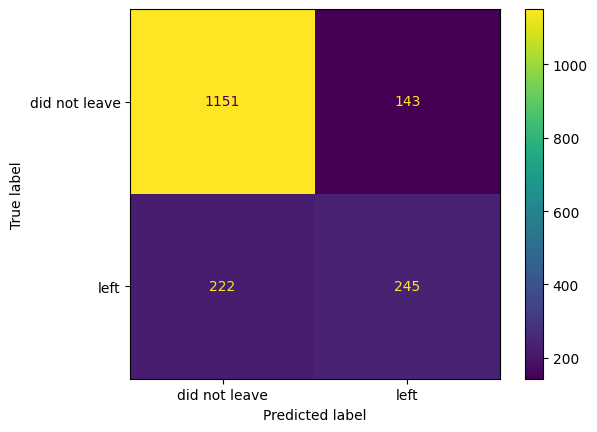

In [33]:
cm1 = confusion_matrix(y_test, predictions, labels=clf_xgb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1,
                              display_labels=["did not leave", "left"])
disp.plot()

### Improve more

penalize incorrect prediction on minority classes (people left)

because **people leaving is more crucial**

**CV**, **Grid Search** on the video

In [34]:
clf_xgb = xgb.XGBClassifier(objective = "binary:logistic",
                            random_state = 42, n_iter_no_change=10,
                            gamma = 0.25,
                            learning_rate = 0.1,
                            max_depth = 4,
                            reg_lambga = 10,
                            scale_pos_weight = 3,
                            subsample = 0.9,
                            eval_metric = "aucpr",
                            colsample_bytree = 0.5)
clf_xgb.fit(X_train, y_train, eval_set = [(X_test, y_test)], verbose = True)

[0]	validation_0-aucpr:0.52527
[1]	validation_0-aucpr:0.53528
[2]	validation_0-aucpr:0.54242
[3]	validation_0-aucpr:0.55399
[4]	validation_0-aucpr:0.56300
[5]	validation_0-aucpr:0.56948
[6]	validation_0-aucpr:0.57759
[7]	validation_0-aucpr:0.58085


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:38:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_iter_no_change", "reg_lambga" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[8]	validation_0-aucpr:0.58501
[9]	validation_0-aucpr:0.58382
[10]	validation_0-aucpr:0.58471
[11]	validation_0-aucpr:0.58583
[12]	validation_0-aucpr:0.58622
[13]	validation_0-aucpr:0.58679
[14]	validation_0-aucpr:0.59467
[15]	validation_0-aucpr:0.59655
[16]	validation_0-aucpr:0.59156
[17]	validation_0-aucpr:0.59484
[18]	validation_0-aucpr:0.59503
[19]	validation_0-aucpr:0.59715
[20]	validation_0-aucpr:0.59688
[21]	validation_0-aucpr:0.59225
[22]	validation_0-aucpr:0.59273
[23]	validation_0-aucpr:0.59226
[24]	validation_0-aucpr:0.59182
[25]	validation_0-aucpr:0.59128
[26]	validation_0-aucpr:0.59491
[27]	validation_0-aucpr:0.59480
[28]	validation_0-aucpr:0.59291
[29]	validation_0-aucpr:0.59359
[30]	validation_0-aucpr:0.59444
[31]	validation_0-aucpr:0.59447
[32]	validation_0-aucpr:0.59525
[33]	validation_0-aucpr:0.59434
[34]	validation_0-aucpr:0.59460
[35]	validation_0-aucpr:0.59512
[36]	validation_0-aucpr:0.59552
[37]	validation_0-aucpr:0.59749
[38]	validation_0-aucpr:0.59797
[39]	valid

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=0.25, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_iter_no_change=10, n_jobs=None, ...)

In [35]:
predictions = clf_xgb.predict(X_test)

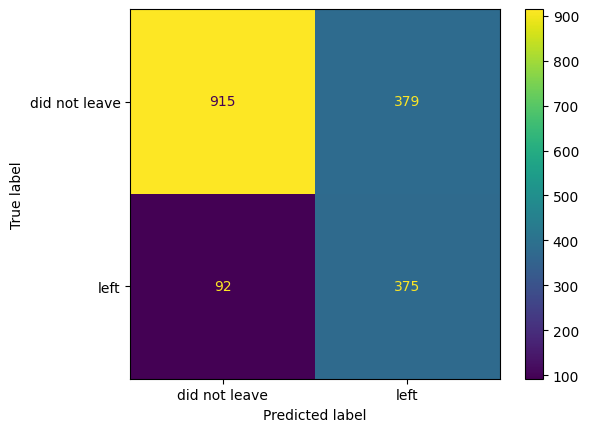

In [36]:
cm2 = confusion_matrix(y_test, predictions, labels=clf_xgb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm2,
                              display_labels=["did not leave", "left"])
disp.plot()

### Visualize model tree

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:38:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_iter_no_change", "reg_lambga" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


weight: {'PaperlessBilling_Yes': 1.0, 'InternetService_Fiber_optic': 3.0, 'OnlineSecurity_Yes': 2.0, 'OnlineBackup_Yes': 1.0, 'Contract_One_year': 1.0, 'Contract_Two_year': 1.0, 'No_internet': 2.0, 'tenure_3': 1.0, 'MonthlyCharges_27': 1.0, 'TotalCharges_21': 1.0}
gain: {'PaperlessBilling_Yes': 5.251363754272461, 'InternetService_Fiber_optic': 126.43228912353516, 'OnlineSecurity_Yes': 19.062973022460938, 'OnlineBackup_Yes': 3.3285369873046875, 'Contract_One_year': 658.5827026367188, 'Contract_Two_year': 1093.6234130859375, 'No_internet': 29.30124282836914, 'tenure_3': 1.41522216796875, 'MonthlyCharges_27': 8.460500717163086, 'TotalCharges_21': 4.111083984375}
cover: {'PaperlessBilling_Yes': 23.461843490600586, 'InternetService_Fiber_optic': 602.8529052734375, 'OnlineSecurity_Yes': 382.1285400390625, 'OnlineBackup_Yes': 80.86848449707031, 'Contract_One_year': 1508.2969970703125, 'Contract_Two_year': 1808.5587158203125, 'No_internet': 314.3637390136719, 'tenure_3': 219.3931884765625, 'Mo

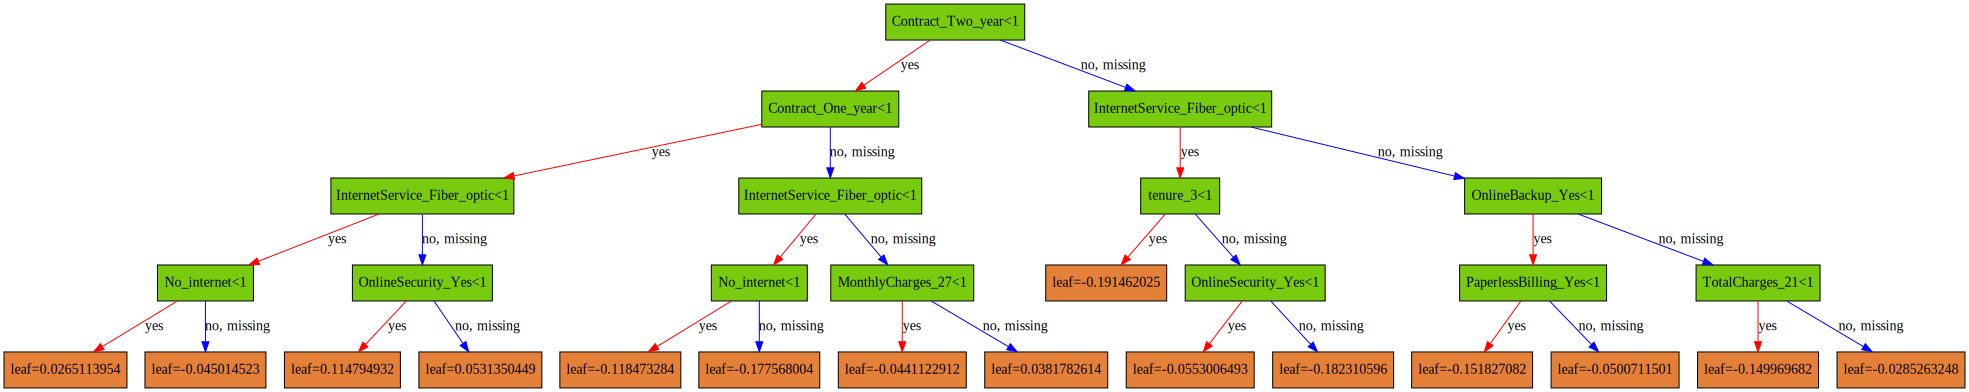

In [37]:
clf_xgb = xgb.XGBClassifier(objective = "binary:logistic",
                            random_state = 42, n_iter_no_change=10,
                            gamma = 0.25,
                            learning_rate = 0.1,
                            max_depth = 4,
                            reg_lambga = 10,
                            scale_pos_weight = 3,
                            subsample = 0.9,
                            eval_metric = "aucpr",
                            colsample_bytree = 0.5,
                            n_estimators = 1)
clf_xgb.fit(X_train, y_train)

bst = clf_xgb.get_booster()
for importance_type in ("weight", "gain", "cover", "total_gain", "total_cover"):
    print("%s:" % importance_type,
          bst.get_score(importance_type=importance_type))

node_params = {"shape": "box",
               "style": "filled, roudned",
               "fillcolor": "#78cbe"}
leaf_params = {"shape": "box",
               "style": "filled",
               "fillcolor": "#e48038"}

xgb.to_graphviz(clf_xgb, num_trees = 0,
                size = "5,5",
                condition_node_params = node_params,
                leaf_node_params = leaf_params)